latest update: GM. 2/21/25


## Package import and some helpful function

In [672]:
# # import python packages, important to keep in this enviornment

import gspread
from google.auth import default
import h5py
import math
import numpy as np
import os
# from os import path
import pandas as pd
# from pandas.core.ops.array_ops import expressions
# import scipy
from scipy.interpolate import interp1d
from scipy.spatial import ConvexHull
from skimage.transform import resize
import re
import ast

In [673]:
def load_helper_funcs():
  %run '/content/drive/MyDrive/Colab Notebooks/Geoff/Social_escape/helper_funcs_SE.ipynb'


In [674]:
# basic processing
def fill_missing(Y, kind="linear"):
    """Fills missing values independently along each dimension after the first.
    Args:
      Y: array like object
      kind: 'linear', refer to scipy.interpolate.interp1d for more options
    Returns:
      np.array
    """
    # Store initial shape.
    initial_shape = Y.shape
    # Flatten after first dim.
    Y = Y.reshape((initial_shape[0], -1))
    # Interpolate along each slice.
    for i in range(Y.shape[-1]):
        y = Y[:, i]
        # Build interpolant.
        x = np.flatnonzero(~np.isnan(y))
        f = interp1d(x, y[x], kind=kind, fill_value=np.nan, bounds_error=False)
        # Fill missing
        xq = np.flatnonzero(np.isnan(y))
        y[xq] = f(xq)
        # Fill leading or trailing NaNs with the nearest non-NaN values
        mask = np.isnan(y)
        y[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), y[~mask])
        # Save slice
        Y[:, i] = y
    # Restore to initial shape.
    Y = Y.reshape(initial_shape)
    return Y

In [675]:
def running_mean(x, N):
    return np.convolve(x, np.ones(N)/N, mode='same')

def normalize_array(inputs):
    output = (inputs-min(inputs))/(max(inputs)-min(inputs))
    return output

In [676]:
def speed_angular_sp(x,y,heading,body_length,frame_rate,scale):
  """ Swimming kinematics of given xy positions over time
  Args:
    x, y (float): arrays of xy coordinates in pixel
    heading (float): arrays of heading direction in degree
    scale (float): value of mm per pixel in experiment video
    body_length (float): arrays of each fish body
    frame_rate (float): video frame rate in Hz
  Returns:
    speed: array of speed and angular speed in px/sec
    angular speed: array of angular speed in dg/sec
  """
  max_speed = 20*body_length # per second
  max_ang_speed = 720 # per second

  # use position difference across 2 inter-frame intervals
  dx = x.flat[2:] - x.flat[:-2]
  dx = np.pad(dx, (1, 1), 'constant', constant_values=(0, 0)) # pad 0 to both ends
  dy = y.flat[2:] - y.flat[:-2]
  dy = np.pad(dy, (1, 1), 'constant', constant_values=(0, 0)) # pad 0 to both ends
  sp = np.sqrt(dx**2+dy**2)/scale*(frame_rate/2)
  sp_filt = np.where(sp > max_speed, np.nan, sp)
  speed = fill_missing(sp_filt)

  # use orientation difference between two consecutive frames
  dag = np.ediff1d(heading, to_begin=0)
  asp = np.array([((d+180)%360 - 180)*frame_rate for d in dag]) # mlb change
  # asp = ((dag+180)%360 - 180)*frame_rate
  asp_filt = np.where(abs(asp) > max_ang_speed, np.nan, asp)
  ang_speed = fill_missing(asp_filt)

  return speed, ang_speed


def speed_calc(f_x,f_y,f_head_angle,body_length,frame_rate,scale):

  max_speed = 20*body_length # per second
  max_ang_speed = 360 # per second

  time = [float(i/frame_rate) for i in range(len(f_x))]

  speed = []
  ang_speed = []
  for ndx,t in enumerate(time):
      sp = math.dist([f_x[ndx],f_y[ndx]],[f_x[ndx-1],f_y[ndx-1]])/(time[ndx]-time[ndx-1])
      asp = (((f_head_angle[ndx]-f_head_angle[ndx-1]) + 180) % 360-180)/(time[ndx]-time[ndx-1])
      if sp < max_speed:
        speed.append(sp)
      else:
        speed.append(speed[-1])

      if abs(asp) < max_ang_speed:
        ang_speed.append(asp)
      else:
        ang_speed.append(ang_speed[-1])

  return speed, ang_speed


#calculate angles between 2 points
def calculate_angle(X1,Y1,X2,Y2):
    rads=[];
    for x1,y1,x2,y2 in zip(X1,Y1,X2,Y2):
        dx=x1-x2
        dy=y1-y2
        rads.append(math.atan2(dy, dx))
    degs = np.rad2deg(rads)
    return degs

def get_single_angle(x1,y1,x2,y2):
    return math.degrees(math.atan2(y2-y1, x2-x1))

In [677]:
def pt_rotate(x, y, deg, self_x, self_y):
    """Rotate a point around a given point.
    Args:
      x, y: arrays of xy coordinates that need to rotate
      self_x, self_y: arrays of xy coordinates that serve as reference point
      deg: orientation angle of the reference point
    Returns:
      qx, qy: new xy coordinates when reference point is at (0,0) facing north
    """
    qx = self_x + math.cos(np.deg2rad(deg))*(x-self_x) + math.sin(np.deg2rad(deg))*(y-self_y)
    qy = self_y - math.sin(np.deg2rad(deg))*(x-self_x) + math.cos(np.deg2rad(deg))*(y-self_y)


    return qx, qy

## (Meta)Data reading and Level 0 processing

In [678]:
def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [679]:
class Fish():
  """Collect individual fish tracking info for easier  data call in pipeline.
  """
  pass

def process_h5(h5tracks,fish_num,sleap_nodes,exp):
  """This script reads xy info of each body node of individual fish in a group.
  Return: list of objects with attributes of xy coordinates.
  """
  frame_num, _, _, track_num = h5tracks.shape
  group_data = []
  for f in range(fish_num):

    name = exp + '_f'+ str(f+1)
    fish = Fish() # make class object
    setattr(fish,'name',name)

    # load all xy coordinates
    for idx, node in enumerate(sleap_nodes):
      setattr(fish,str(node)+'x',fill_missing(h5tracks[:,idx,0,f]))
      setattr(fish,str(node)+'y',fill_missing(h5tracks[:,idx,1,f]))
      #print(str(node))
    group_data.append(fish)

  return group_data

def process_h5_single_animal(h5tracks,sleap_nodes):
  """This script reads xy info of each body node for a single animal and return them into 2 arrays (length = frame_num).
  """
  frame_num, _, _, track_num = h5tracks.shape
  fish_data_x = np.empty((frame_num))
  fish_data_y = np.empty((frame_num))

  for f in range(track_num):

    for idx, node in enumerate(sleap_nodes):
      fish_data_x[idx] = fill_missing(h5tracks[:,idx,0,f])
      fish_data_y[idx] = fill_missing(h5tracks[:,idx,1,f])

  return fish_data_x,fish_data_y

In [680]:
def group_arrays(group_data,fish_num,frame_num,frame_rate,scale):
  """This script takes the processed h5 data and stacks them into group arrays shaped in fish_num x frame_num.
  """
  # initialize group arrays
  f_bodylength_mm = [[] for f in range(fish_num)]
  f_bodylength_px = [[] for f in range(fish_num)]

  # postional (mlb updated)
  f_nosex = [[] for f in range(fish_num)]; f_nosey = [[] for f in range(fish_num)] # center of two eyes
  f_x = [[] for f in range(fish_num)]; f_y = [[] for f in range(fish_num)] # front bladder or belly as the centroid
  f_lex = [[] for f in range(fish_num)]; f_ley = [[] for f in range(fish_num)] # left eye
  f_rex = [[] for f in range(fish_num)]; f_rey = [[] for f in range(fish_num)] # right eye
  f_tailx = [[] for f in range(fish_num)]; f_taily = [[] for f in range(fish_num)] # tip of the tail
  # angular
  f_heading = [[] for f in range(fish_num)]; f_tail_angle = [[] for f in range(fish_num)]
  f_disp_heading = [[] for f in range(fish_num)]; f_tail_angle = [[] for f in range(fish_num)]
  # speed stuff
  f_speed = [[] for f in range(fish_num)]; f_ang_speed = [[] for f in range(fish_num)]

  # set window size (num of frame) for running mean
  pos_ker = 5 # for positional data
  ang_ker = 5 # for angular data
  spd_ker = 10 # for speed data

  # loop through the individual fish
  for ndx, fish in enumerate(group_data):
    disp_heading = [];
    # get ind nose - centr of two eyes
    nosex = [int(np.mean([l,r])) for l,r in zip(fish.lex,fish.rex)]
    nosey = [int(np.mean([l,r])) for l,r in zip(fish.ley,fish.rey)]

    # get ind fish body length - 95th percentil across the frames
    nose_to_tail = np.sqrt( (nosex - fish.t1x)**2 + (nosey - fish.t1y)**2 )
    bodylen_px =  np.percentile(nose_to_tail,99)
    bodylen_mm =  np.percentile(nose_to_tail,99)*scale

    # stack the convolved arrays
    f_bodylength_px[ndx] = bodylen_px
    f_bodylength_mm[ndx] = bodylen_mm

    f_nosex[ndx] = running_mean(nosex,pos_ker)
    f_nosey[ndx] = running_mean(nosey,pos_ker)

    f_lex[ndx] = running_mean(fish.lex,pos_ker)
    f_ley[ndx] = running_mean(fish.ley,pos_ker)
    f_rex[ndx] = running_mean(fish.rex,pos_ker)
    f_rey[ndx] = running_mean(fish.rey,pos_ker)

    f_x[ndx] = running_mean(fish.mbx,pos_ker) #if jy nodes
    f_y[ndx] = running_mean(fish.mby,pos_ker) #if jy nodes
    # f_x[ndx] = running_mean(fish.byx,pos_ker) #if dz nodes
    # f_y[ndx] = running_mean(fish.byy,pos_ker) #if dz nodes
    f_tailx[ndx] = running_mean(fish.t1x,pos_ker)
    f_taily[ndx] = running_mean(fish.t1y,pos_ker)

    # get ind fish orientation and tail angle per frame
    heading = calculate_angle(f_nosex[ndx],f_nosey[ndx],f_x[ndx],f_y[ndx])
    tail = calculate_angle(f_x[ndx],f_y[ndx],f_tailx[ndx],f_taily[ndx])

    diff_x = np.diff(f_x[ndx])
    diff_y = np.diff(f_y[ndx])
    for time_ndx in range(len(f_x[ndx])-1):
      disp_rads = math.atan2(diff_y[time_ndx],diff_x[time_ndx])
      disp_heading.append(np.rad2deg(disp_rads))

    f_disp_heading[ndx] = running_mean(disp_heading, ang_ker)
    # f_disp_heading[ndx] = f_disp_heading[ndx].ewm(span = 10, adjust=False).mean()
    f_heading[ndx] = running_mean(heading, ang_ker)
    f_tail_angle[ndx] = running_mean((( (tail-heading) + 180) % 360) - 180, ang_ker)

    # get ind fish speed and angular speed per frame
    speed, angular_speed = speed_angular_sp(fish.mbx,fish.mby,heading,bodylen_px,frame_rate,scale) #if jy nodes
    # speed, angular_speed = speed_angular_sp(fish.byx,fish.byy,heading,bodylen_px,frame_rate,scale) #if dz nodes

    f_speed[ndx] = running_mean(speed, spd_ker)
    f_ang_speed[ndx] = running_mean(angular_speed, spd_ker)

  return f_bodylength_px, f_bodylength_mm, f_nosex, f_nosey, f_x, f_y, f_tailx, f_taily, f_heading, f_tail_angle, f_speed, f_ang_speed, f_disp_heading, f_lex, f_ley, f_rex, f_rey

In [681]:
def analyze_neighbors(fish_num,f_heading,f_x,f_y,frame_num,scale,f_body_length):
  """This script generates group arrays of distance and alignment between individual fish and their neighbors.
  """

  if fish_num == 2:

    # initialize arrays
    ff_dist = np.zeros((fish_num,fish_num-1,frame_num))
    ff_align = np.zeros((fish_num,fish_num-1,frame_num))
    ff_heading = np.zeros((fish_num,fish_num-1,frame_num))
    ff_speed = np.zeros((fish_num,fish_num-1,frame_num))

    f_closest_id = np.zeros((fish_num,frame_num))
    f_closest_dist = np.zeros((fish_num,frame_num))
    f_closest_align = np.zeros((fish_num,frame_num))
    f_closest_heading = np.zeros((fish_num,frame_num))
    f_closest_speed = np.zeros((fish_num,frame_num))

    for f0 in range(fish_num):
      for f1 in range(fish_num):
        if f1 != f0:
          dist = np.abs(np.sqrt( (f_x[f0]-f_x[f1])**2 + (f_y[f0]-f_y[f1])**2 ) )*scale
          align = ((( f_heading[f0]-f_heading[f1] ) + 180) % 360 - 180)

          ff_dist[f0][0] = dist
          ff_align[f0][0] = align
          ff_heading[f0] = f_heading[f1]
          ff_speed[f0] = f_speed[f1]

    f_IID = ff_dist[0]
    f_IIA = ff_align[0]
    #
    f_closest_id = np.stack( (np.ones((frame_num)), np.zeros((frame_num))) )
    f_closest_dist = ff_dist # ff_dist[f0] ? julia on 7/2/24
    f_closest_align = ff_align
    f_closest_heading = ff_heading
    f_closest_speed = ff_speed

  else: # if fish_num >= 3

    # initialize arrays and lists
    ff_dist = np.zeros((fish_num,fish_num-1,frame_num))
    ff_align = np.zeros((fish_num,fish_num-1,frame_num))
    ff_heading = np.zeros((fish_num,fish_num-1,frame_num))
    ff_speed = np.zeros((fish_num,fish_num-1,frame_num))

    f_IID = []; f_IIA = [] # number of dyads x framenum
    f_closest_id = np.zeros((fish_num,frame_num))
    f_closest_dist = np.zeros((fish_num,frame_num))
    f_closest_align = np.zeros((fish_num,frame_num))
    f_closest_heading = np.zeros((fish_num,frame_num))
    f_closest_speed = np.zeros((fish_num,frame_num))

    # loop through ind fish
    for f0 in range(fish_num):
      nb_count = 0

      for f1 in range(fish_num):
        if f1 != f0:
          nb_count += 1

          dist = np.abs(np.sqrt( (f_x[f0]-f_x[f1])**2 + (f_y[f0]-f_y[f1])**2 ) )*scale
          align = ((( f_heading[f0]-f_heading[f1] ) + 180) % 360 - 180)

          ff_dist[f0][nb_count-1] = dist
          ff_align[f0][nb_count-1] = align
          ff_heading[f0][nb_count-1] = f_heading[f1]
          ff_speed[f0][nb_count-1] = f_speed[f1]

        if f0 < f1:
          f_IID.append(dist)
          f_IIA.append(align)

    f_IID = np.array(f_IID)
    f_IIA = np.array(f_IIA)

    # find the stats with the closest neighbor for each fish
    for f0 in range(fish_num):
      closest_dist = np.array(np.min(ff_dist[f0],axis=0)) # find the smallest dist in each frame
      f_closest_id[f0] = np.argmin(ff_dist[f0] == closest_dist, axis=0) # identify which fish it is
      index = f_closest_id[f0].astype(int)
      f_closest_dist[f0] = closest_dist # find their distance
      f_closest_align[f0] = ff_align[f0][index,np.arange(len(index))] # find their alignment
      f_closest_heading[f0] = ff_heading[f0][index,np.arange(len(index))]
      f_closest_speed[f0] = ff_speed[f0][index,np.arange(len(index))]

  return ff_dist, ff_align, f_IID, f_IIA, f_closest_id, f_closest_dist, f_closest_align, f_closest_heading, f_closest_speed

In [682]:
def save_npz(save_path,experiment,filename,savinglist):
  """This script saves processed data into npz (1 npz per experiment recording).
  Args: savinglist (dictionary with name and values of each numpy array)
  """
  os.makedirs(save_path + experiment, exist_ok=True)

  # initizlize a dictionary for variables to save
  savez_dict = dict()

  # fill in the dictionary with variable names + values
  for key, value in savinglist.items():
    savez_dict[str(key)] = value

  # save npz
  np.savez(save_path + experiment + '/' + experiment + '_' + filename +'.npz', **savez_dict)

# Level 1 processing

In [683]:
def egocentric_occupancy(fish_num,f_x,f_y,f_heading,f_speed,f_ang_speed,start,stop,imsize,subsize,sample):
  """This scripts generates egocentric occupancy matrices for each fish.
  Returns:
    3D arrays (fish_num,frames,(subsize,subsize))
  """
  sample = sample # sampling rate - take every Nth frames
  offset = int(imsize/2) # max distance of neighbor position from foca fish to be include
  frame_num = len(f_y[0][start:stop:sample]) #number of timepoints

  # initialize empty 3D matrix (fishnum,framenum,imsize,imsize)

  __occupancy_maps=[]

  # for each focal fish
  for f0 in range(fish_num):

    omap=np.zeros([frame_num,imsize,imsize])

    # loop through each neighbor
    for f1 in range(fish_num):
      if f1 != f0:

        # sample the focal fish data
        x_0, y_0 = f_x[f0][start:stop:sample], f_y[f0][start:stop:sample]
        heading_0 = f_heading[f0][start:stop:sample]

        # sample the neighbor fish data
        x_1,y_1 = f_x[f1][start:stop:sample],f_y[f1][start:stop:sample]
        heading_1 = f_heading[f1][start:stop:sample]

        # go through each observation
        for ndx,(d0,d1,x0,x1,y0,y1) in enumerate(zip(heading_0,heading_1,x_0,x_1,y_0,y_1)):

          # rotate the neighbor fish position and heading based on focal fish
          x1_rot, y1_rot = pt_rotate(x1, y1, d0, x0, y0)
          #of other fish within region, add to map
          if abs(x0-x1_rot)<offset and abs(y0-y1_rot)<offset:
            #add in condition that fish is not at extremes of dish
            omap[ndx,int(x0-x1_rot)+offset,int(y0-y1_rot)+offset]=1

  __occupancy_maps.append(omap)
  del(omap)

  #Merge across fish and resize, for each timepoint
  f_occupancy_maps = np.array([resize(M,(subsize,subsize)) for M in np.sum(__occupancy_maps, axis=0)])

  return f_occupancy_maps


def egocentric_alignment(fish_num,f_x,f_y,f_heading,f_speed,f_ang_speed,start,stop,imsize,subsize,sample):
  """This scripts generates egocentric alignment probability matrices for each fish.
  Returns:
    3D arrays (fish_num,frames,(subsize,subsize))
  """
  sample = sample # sampling rate - take every Nth frames
  offset = int(imsize/2) # max distance of neighbor position from foca fish to be include
  frame_num = len(f_y[0][start:stop:sample]) #number of timepoints

  __alignment_maps=[]

  # for each focal fish
  for f0 in range(fish_num):

    amap=np.full([frame_num,imsize,imsize], 180)

    # loop through each neighbor
    for f1 in range(fish_num):
      if f1 != f0:

        # sample the focal fish data
        x_0, y_0 = f_x[f0][start:stop:sample], f_y[f0][start:stop:sample]
        heading_0 = f_heading[f0][start:stop:sample]

        # sample the neighbor fish data
        x_1,y_1 = f_x[f1][start:stop:sample],f_y[f1][start:stop:sample]
        heading_1 = f_heading[f1][start:stop:sample]

        # go through each observation
        for ndx,(d0,d1,x0,x1,y0,y1) in enumerate(zip(heading_0,heading_1,x_0,x_1,y_0,y_1)):

          # rotate the neighbor fish position and heading based on focal fish
          x1_rot, y1_rot = pt_rotate(x1, y1, d0, x0, y0)
          #of other fish within region, add to map
          if abs(x0-x1_rot)<offset and abs(y0-y1_rot)<offset:
            amap[ndx,int(x0-x1_rot)+offset,int(y0-y1_rot)+offset]=abs(((d1-d0) + 180) % 360-180)

  __alignment_maps.append(amap)
  del(amap)

  #Merge across fish and resize, for each timepoint
  f_alignment_maps = np.array([resize(M,(subsize,subsize)) for M in np.mean(__alignment_maps, axis=0)])

  return f_alignment_maps



def egocentric_speed(fish_num,f_x,f_y,f_heading,f_speed,f_ang_speed,start,stop,imsize,subsize,sample):
  """This scripts generates egocentric speed matrices for each fish.
  Returns:
    3D arrays (fish_num,frames,(subsize,subsize))
  """
  sample = sample # sampling rate - take every Nth frames
  offset = int(imsize/2) # max distance of neighbor position from foca fish to be include
  frame_num = len(f_y[0][start:stop:sample]) #number of timepoints

  f_speed_maps=[[] for n in range(fish_num)]
  f_ang_speed_maps=[[] for n in range(fish_num)]

  #for each moment in time:
  frames = range(len(f_x[0][start:stop:sample]))

  for frame_index in frames:
    #for each focal fish
    for f0 in range(fish_num):
      x0, y0 = f_x[f0][frame_index], f_y[f0][frame_index]
      d0 = f_heading[f0][frame_index]
      speed_0,ang_sp_0 = f_speed[f0][frame_index],f_ang_speed[f0][frame_index]

      tmp_s=np.zeros([imsize,imsize])
      tmp_as=np.zeros([imsize,imsize])

      #for each neighbor
      for f1 in range(fish_num):
        if f1 != f0:
          x1,y1 = f_x[f1][frame_index],f_y[f1][frame_index]
          #place neighbor in eogentric position
          a,b = pt_rotate(x1,y1,d0,x0,y0)

          if abs(x0-a)<offset and abs(y0-b)<offset:
            #append speed to map
            tmp_s[int(x0-a)+offset,int(y0-b)+offset]=speed_0
            tmp_as[int(x0-a)+offset,int(y0-b)+offset]=ang_sp_0

      f_speed_maps[f0].append(resize(tmp_s,(subsize,subsize)))
      f_ang_speed_maps[f0].append(resize(tmp_as,(subsize,subsize)))

  return f_speed_maps, f_ang_speed_maps

def arena_occupancy(fish_num,f_x,f_y,f_heading,f_speed,f_ang_speed,start,stop,imsize,subsize,sample):
  """This scripts generates egocentric occupancy matrices for each fish.
  Returns:
    3D arrays (fish_num,frames,(subsize,subsize))
  """
  sample = sample # sampling rate - take every Nth frames
  frame_num = len(f_y[0][start:stop:sample]) #number of timepoints

  __occupancy_maps=[]

  # for each focal fish
  for f0 in range(fish_num):

    omap = np.zeros([frame_num,imsize,imsize])
    x_0, y_0 = f_x[f0][start:stop:sample], f_y[f0][start:stop:sample]

    # go through each observation
    for ndx,(x0,y0) in enumerate(zip(x_0,y_0)):
      omap[ndx,int(x0),int(y0)]=1

  __occupancy_maps.append(omap)
  del(omap)

  #Merge across fish and resize, for each timepoint
  f_occupancy_maps = np.array([resize(M,(subsize,subsize)) for M in np.sum(__occupancy_maps, axis=0)])

  return f_occupancy_maps

In [684]:
def fish_polygon_area(xs,ys):
    """Calculate the area of a polygon given its vertices."""
    xs=np.array(xs).T
    ys=np.array(ys).T
    areas=[]
    for f_x,f_y in zip(xs,ys):
      points=[[x,y] for x,y in zip(f_x,f_y)]
      hull=ConvexHull(np.array(points))
      areas.append(hull.area)

    return areas

# Level 2 processing

In [685]:
def get_visual_fields(fish_num,f_x,f_y,f_heading,f_bodylength,start,stop,scale,sample):

  occupied_angles=[]

  # for each focal fish
  for f0 in range(fish_num):
    fish_tmp = []
    # loop through each neighbor
    for f1 in range(fish_num):
      if f1 != f0:
        tmp=[]

        #fish details
        x_0, y_0 = f_x[f0][start:stop:sample], f_y[f0][start:stop:sample]
        heading_0 = f_heading[f0][start:stop:sample]
        x_1, y_1 = f_x[f1][start:stop:sample], f_y[f1][start:stop:sample]
        heading_1 = f_heading[f1][start:stop:sample]
        bodylength_1 = f_bodylength/scale

        for ndx,(d0,d1,x0,x1,y0,y1) in enumerate(zip(heading_0,heading_1,x_0,x_1,y_0,y_1)):
            x1_rot, y1_rot = pt_rotate(x1, y1, d0, x0, y0)

            # Calculate the position of the endpoints of the line
            endpoint1_x = x1_rot + bodylength_1/2.0 * np.cos(d1)
            endpoint1_y = y1_rot + bodylength_1/2.0 * np.sin(d1)

            endpoint2_x = x1_rot - bodylength_1/2.0 * np.cos(d1)
            endpoint2_y = y1_rot - bodylength_1/2.0 * np.sin(d1)

            angle1 = np.arctan2(endpoint1_y, endpoint1_x)
            angle2 = np.arctan2(endpoint2_y, endpoint2_x)

            tmp.append([min(angle1, angle2), max(angle1, angle2)])

        fish_tmp.append(tmp)
        del(tmp)
    occupied_angles.append(fish_tmp)
    del(fish_tmp)

  return occupied_angles


In [686]:
def save_npz_geoff(save_path,experiment,filename,savinglist,save=True):
  """This script saves processed data into npz (1 npz per experiment recording).
  Args: savinglist (dictionary with name and values of each numpy array)
  """
  #make folder for each recording
  newDir=save_path+'/'+experiment
  saveDir = newDir + '/' + experiment + '_' + filename +'.npz'
  if save==True:
    os.makedirs(newDir, exist_ok=True)

    # initizlize a dictionary for variables to save
    savez_dict = dict()

    # fill in the dictionary with variable names + values
    for key, value in savinglist.items():
      savez_dict[str(key)] = value

    # save npz
    np.savez(newDir + '/' + experiment + '_' + filename +'.npz', **savez_dict)
  return saveDir

In [687]:
#Update metadata

def extract_between_d_and_edit(url):
    # Regular expression to find text between /d/ and /edit
    match = re.search(r'/d/([^/]+)/edit', url)
    if match:
        return match.group(1)  # Return the captured group
    else:
        print("No match found.")
    return None  # Return None if no match is found

def updateMetadata(ID):
  from google.colab import auth
  auth.authenticate_user()
  import gspread
  from google.auth import default
  from oauth2client.client import GoogleCredentials

  creds, _ = default()
  gc = gspread.authorize(creds)

  # Assuming 'metadata' is your pandas DataFrame
  # and it exists in the current environment

  # Replace 'Your spreadsheet name' with the actual name or ID of your spreadsheet
  # If the spreadsheet doesn't exist, it will be created.
  SpreadSheetID=gsheet
  sh = gc.open_by_key(ID) #replace with your spreadsheet id

  # Select the first worksheet (or create one if it doesn't exist)
  worksheet = sh.get_worksheet(0) # 0 for the first sheet

  # Convert the DataFrame to a list of lists, including the index
  metadata_list = metadata.reset_index().values.tolist()

  # Add the header row (this part remains the same)
  header = metadata.reset_index().columns.tolist()  # Use reset_index() here as well
  metadata_list.insert(0, header)


  # Update the worksheet with the data
  worksheet.update('A1', metadata_list)

  print(f"Metadata saved to Google Sheet: {sh.title}")


In [688]:
def getTimeStamps(time_stamp_path):
  time_stamps_df = pd.read_csv(time_stamp_path)
  time_stamps_df.columns = ['time_stamps']
  time_stamps_df['time_stamps'] = pd.to_datetime(time_stamps_df['time_stamps'], errors='coerce')
  time_stamps_df['elapsed_seconds'] = (time_stamps_df['time_stamps'] - time_stamps_df['time_stamps'].iloc[0]).dt.total_seconds()
  return time_stamps_df



In [689]:
import numpy as np

def binDataFromEllapsedTime(data, EllapsedTime, binLength):
    max_idx = np.round(max(EllapsedTime))  # Get the max time rounded
    numBins = int(np.ceil(max_idx / binLength))  # Ensure full coverage
    TimeBins = np.arange(0, numBins * binLength, binLength)  # Create consistent bins

    binned_data = []
    binIdx = [0]

    # Find closest indices for each bin boundary
    for t in TimeBins:
        index = np.abs(EllapsedTime - t).argmin()  # Find closest index to bin
        if index > binIdx[-1]:  # Avoid duplicate indices
            binIdx.append(index)

    # Bin data using computed indices
    for ii in range(len(binIdx) - 1):
        bd = np.nanmean(data[0, binIdx[ii]:binIdx[ii+1]])  # Fix indexing
        binned_data.append(bd)

    return binned_data, TimeBins - TimeBins[0]

def get_escape_data(EllapsedTime,fish_showing,fish_escaping):
    #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)


    #Find transitions in showing/escaping (i.e. start and stop indexes)
    fs_idx=np.where(np.diff(fish_showing.astype(int))==1)[0]-1
    fse_idx=np.where(np.diff(fish_showing.astype(int))==-1)[0]-1

    fe_idx=np.where(np.diff(fish_escaping.astype(int))==1)[0]-1

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]-1])
      end_fs.append(EllapsedTime[fse_idx[x]-1])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop in zip(start_fe,end_fe):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop})
    fe_df=pd.DataFrame(fe_results)


    return fs_df,fe_df

def binDataFishEscape(data, EllapsedTime, binLength,fish_showing,fish_escaping):
    max_idx = np.round(max(EllapsedTime))  # Get the max time rounded
    numBins = int(np.ceil(max_idx / binLength))  # Ensure full coverage
    #TimeBins = np.arange(0, numBins * binLength, binLength)  # Create consistent bins
    TimeBins = np.arange(0,max_idx,binLength)
    binned_data = []
    binned_fish_showing = []
    binned_fish_escaping = []
    binIdx = [0]

    # Find closest indices for each bin boundary
    for t in TimeBins:
        index = np.abs(EllapsedTime - t).argmin()  # Find closest index to bin
        binIdx.append(index)

    # Bin data using computed indices
    for ii in range(len(binIdx) - 1):
        bd = np.nanmean(data[0, binIdx[ii]:binIdx[ii+1]])  # Fix indexing
        binned_data.append(bd)

    #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)


    #Find transitions in showing/escaping (i.e. start and stop indexes)
    fs_idx=np.where(np.diff(fish_showing.astype(int))==1)[0]
    fse_idx=np.where(np.diff(fish_showing.astype(int))==-1)[0]

    fe_idx=np.where(np.diff(fish_escaping.astype(int))==1)[0]

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]-1])
      end_fs.append(EllapsedTime[fse_idx[x]-1])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFS":start,"EndFS":stop})
    fs_df=pd.DataFrame(fs_results)
    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop in zip(start_fe,end_fe):
      fe_results.append({"StartFS":start,"EndFS":stop})
    fe_df=pd.DataFrame(fe_results)


    return binned_data, TimeBins - TimeBins[0],fs_df,fe_df



In [690]:
def binDataFishEscapeSpeed(data, EllapsedTime, binLength,fish_showing,fish_escaping):
    max_idx = np.round(max(EllapsedTime))  # Get the max time rounded
    numBins = int(np.ceil(max_idx / binLength))  # Ensure full coverage
    TimeBins = np.arange(0, numBins * binLength, binLength)  # Create consistent bins

    binned_data = []
    binned_fish_showing = []
    binned_fish_escaping = []
    binIdx = [0]

    # Find closest indices for each bin boundary
    for t in TimeBins:
        index = np.abs(EllapsedTime - t).argmin()  # Find closest index to bin
        if index > binIdx[-1]:  # Avoid duplicate indices
            binIdx.append(index)

    # Bin data using computed indices
    for ii in range(len(binIdx) - 1):
        bd = np.nansum(data[0, binIdx[ii]:binIdx[ii+1]])  # Total distance traveled per
        binned_data.append(bd)

    #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)


    #Find transitions in showing/escaping (i.e. start and stop indexes)
    fs_idx=np.where(np.diff(fish_showing.astype(int))==1)[0]
    fse_idx=np.where(np.diff(fish_showing.astype(int))==-1)[0]

    fe_idx=np.where(np.diff(fish_escaping.astype(int))==1)[0]

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]-1])
      end_fs.append(EllapsedTime[fse_idx[x]-1])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFS":start,"EndFS":stop})
    fs_df=pd.DataFrame(fs_results)
    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop in zip(start_fe,end_fe):
      fe_results.append({"StartFS":start,"EndFS":stop})
    fe_df=pd.DataFrame(fe_results)


    return binned_data, TimeBins - TimeBins[0],fs_df,fe_df


In [691]:
def find_consecutive_ones(arr):
    arr = np.asarray(arr)  # Ensure input is a NumPy array
    diff = np.diff(np.concatenate(([0], arr, [0])))  # Add padding for edge cases
    start_indices = np.where(diff == 1)[0]  # Where 0 → 1 (start of a sequence)
    end_indices = np.where(diff == -1)[0] - 1  # Where 1 → 0 (end of a sequence)

    return list(zip(start_indices, end_indices))



In [692]:
def find_engagement_bouts(results,wall,StartStim,is_inside,EllapsedTime,con):
  BeforeStart=0
  BeforeEnd=np.where(EllapsedTime<StartStim)[0][-1]
  is_inside_before=is_inside[BeforeStart:BeforeEnd]
  indices=find_consecutive_ones(is_inside_before)
  for i in range(len(indices)):
      start=indices[i][0]
      end=indices[i][1]
      engagement_length = EllapsedTime[end-1]- EllapsedTime[start]
      if engagement_length > 0:
        results.append({
            "Fish": exp,
            "Condition": con,
            "Wall": wall,
            "Stim": "Before",
            "Engagement_Length": engagement_length
        })

  AfterStart=np.where(EllapsedTime>=StartStim)[0][0]
  AfterEnd=len(EllapsedTime)-1
  is_inside_after=is_inside[AfterStart:AfterEnd]
  indices=find_consecutive_ones(is_inside_after)
  for i in range(len(indices)):
      start=indices[i][0]
      end=indices[i][1]
      engagement_length = EllapsedTime[end-1]- EllapsedTime[start]
      if engagement_length > 0:
        results.append({
            "Fish": exp,
            "Condition": con,
            "Wall": wall,
            "Stim": "After",
            "Engagement_Length": engagement_length
        })
  return results


In [693]:
def save_data_as_google_sheet(engagement_df,name,analysis_path):
  import pandas as pd
  import gspread
  from google.oauth2.service_account import Credentials

  #Authenticate with Google Sheets API
  #1.  Go to the Google Cloud Platform Console.
  #2. Create or select a project.
  #3. Click on the Navigation menu and select "APIs & Services".
  #4. Click on the "+ ENABLE APIS AND SERVICES" button.
  #5. Search for "Google Sheets API" and enable it.
  #6. Create a service account.
  #7. Download the JSON key file for the service account.
  #8. Set the GOOGLE_APPLICATION_CREDENTIALS environment variable to the path of the JSON key file.


  scopes = ['https://www.googleapis.com/auth/spreadsheets',
            'https://www.googleapis.com/auth/drive']
  # credentials = Credentials.from_service_account_file(
  #     '/content/drive/MyDrive/Personal_notebooks/Geoff_Notebook/Behavior_analysis/Pseudo_school/Data/pseudo-school-data-analysis-4a710b429856.json', scopes=scopes)
  # gc = gspread.authorize(credentials)

  creds, _ = default()
  gc = gspread.authorize(creds)
  # Open or create the Google Sheet
  try:
      sh = gc.open(name)
  except gspread.SpreadsheetNotFound:
      sh = gc.create(name)

  # Select the worksheet (create if it doesn't exist)
  try:
      worksheet = sh.worksheet("Sheet1")  # Try to open existing worksheet
  except gspread.WorksheetNotFound:
      worksheet = sh.add_sheet(title="Sheet1")  # Create if it doesn't exist

  # Clear existing data in the worksheet (optional)
  worksheet.clear()

  # Convert the DataFrame to a list of lists
  data = [engagement_df.columns.tolist()] + engagement_df.values.tolist()

  # Update the worksheet with the data
  worksheet.update(data)

  # Move the spreadsheet to the analysis_path in Google Drive
  # Note: analysis_path needs to be a Google Drive folder ID
  # Get the spreadsheet ID
  spreadsheet_id = sh.id
  # Move the spreadsheet to the analysis_path folder
  sh.move(analysis_path)

In [694]:
def get_BBOX_IDX(BoxDims,vid_name):
  " returns IDX of correct BBOX dims based on vid_name"
  bboxNames=BoxDims['Video Path']
  subsetBBOX_names=[]
  for i in range(len(bboxNames)):
    path=bboxNames.iloc[i]
    last_element = path.split("\\")[-1]
    last_element = last_element.split('.')[0]
    subsetBBOX_names.append(last_element)
  #print(np.array(subsetBBOX_names))
  bboxIdx=np.where(np.array(subsetBBOX_names)==np.array(vid_name))[0]
  return bboxIdx

def get_arena_dims(data):
  ArenaDims=pd.DataFrame(data['ArenaDims'].item())
  ArenaDims['Points'] = ArenaDims['Points'].apply(ast.literal_eval)

  #Calculate width based on selected points
  TopXY_L=np.array([ArenaDims['Points'].iloc[0][0][0],ArenaDims['Points'].iloc[0][0][1]])
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  ArenaWidth=np.sqrt(np.sum(((TopXY_L-TopXY_R)**2))).astype(int)

  #Calculate height based on selected points
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  BottomXY_R=np.array([ArenaDims['Points'].iloc[0][2][0],ArenaDims['Points'].iloc[0][2][1]])
  ArenaHeight=np.sqrt(np.sum(((TopXY_R-BottomXY_R)**2))).astype(int)


  #Store values in array
  ArenaDims['BBW']=ArenaWidth
  ArenaDims['BBH']=ArenaHeight
  return ArenaDims

In [695]:
def read_metadata_from_csv(file_path):
    """Reads metadata from a CSV file and returns it as a pandas DataFrame."""
    try:
        metadata_df = pd.read_csv(file_path)
        data=metadata_df.set_index('experiment')
        display(data)
        return data
    except Exception as e:
        print(f"Error reading metadata from {file_path}: {e}")
        return None
    

In [696]:
metadata=read_metadata_from_csv("C:\\Users\\samis\\OneDrive\\Documents\\LabBoids\\BOIDs\\h5_files\\Light-Dark_Exp\\metadata_for_Zada_et_al - Sheet1.csv")

,time_stamps,fish_num,exp_type,bio_rep,tech_rep,fish_cohort,fps_Hz,rig_mm,vid_px,body_length,experiment_date
experiment,,,,,,,,,,,
labels.vDavid_all_2wks.009_2wpf_061622_4.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_4wpf_060222_1.analysis.h5,NaN,4,4wpf,NaN,1,NaN,121,150,1000,8,Davids_data_development
labels.vDavid_all_2wks.008_2wpf_061622_3.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_all_2wks.007_2wpf_061622_2.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_all_2wks.006_2wpf_061622_1.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_all_2wks.005_2wpf_091522_6.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_all_2wks.004_2wpf_091522_5.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_all_2wks.003_2wpf_091522_4.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development
labels.vDavid_all_2wks.002_2wpf_091522_3.analysis.h5,NaN,4,2wpf,NaN,1,NaN,121,150,1000,6,Davids_data_development


In [697]:
print(metadata.columns.tolist())
print(metadata.head())

['time_stamps', 'fish_num', 'exp_type', 'bio_rep', 'tech_rep', 'fish_cohort', 'fps_Hz', 'rig_mm', 'vid_px', 'body_length', 'experiment_date']
                                                    time_stamps  fish_num  \
experiment                                                                  
labels.vDavid_all_2wks.009_2wpf_061622_4.analys...          NaN         4   
labels.vDavid_4wpf_060222_1.analysis.h5                     NaN         4   
labels.vDavid_all_2wks.008_2wpf_061622_3.analys...          NaN         4   
labels.vDavid_all_2wks.007_2wpf_061622_2.analys...          NaN         4   
labels.vDavid_all_2wks.006_2wpf_061622_1.analys...          NaN         4   

                                                   exp_type  bio_rep  \
experiment                                                             
labels.vDavid_all_2wks.009_2wpf_061622_4.analys...     2wpf      NaN   
labels.vDavid_4wpf_060222_1.analysis.h5                4wpf      NaN   
labels.vDavid_all_2wks.008_2wp

In [698]:
data_path="C:\\Users\\samis\\OneDrive\\Documents\\LabBoids\\BOIDs\\h5_files\\Light-Dark_Exp\\labels.vDavid_8wpf_070122_L3.analysis.h5"
exps=metadata.index.tolist()
exp_index=0
for i, exp in enumerate(exps):
    broken_exp=exp.split("_")
    new_exp_light=""
    new_exp_dark=""
    for j, part in enumerate(broken_exp):
        if j!=len(broken_exp)-1:
            new_exp_light+=part+"_"
            new_exp_dark+=part+"_"
        else:
            new_exp_light+="L"+part+"_"
            new_exp_dark+="D"+part+"_"
    new_exp_light=new_exp_light[:-1]
    new_exp_dark=new_exp_dark[:-1]
    print(new_exp_light, new_exp_dark)
    if new_exp_light in data_path or new_exp_dark in data_path:
        exp_index=i
        break
print(f"Experiment index: {exp_index}")


h5_obj = h5py.File(data_path, "r")
h5tracks = h5_obj['tracks'][:].T


labels.vDavid_all_2wks.009_2wpf_061622_L4.analysis.h5 labels.vDavid_all_2wks.009_2wpf_061622_D4.analysis.h5
labels.vDavid_4wpf_060222_L1.analysis.h5 labels.vDavid_4wpf_060222_D1.analysis.h5
labels.vDavid_all_2wks.008_2wpf_061622_L3.analysis.h5 labels.vDavid_all_2wks.008_2wpf_061622_D3.analysis.h5
labels.vDavid_all_2wks.007_2wpf_061622_L2.analysis.h5 labels.vDavid_all_2wks.007_2wpf_061622_D2.analysis.h5
labels.vDavid_all_2wks.006_2wpf_061622_L1.analysis.h5 labels.vDavid_all_2wks.006_2wpf_061622_D1.analysis.h5
labels.vDavid_all_2wks.005_2wpf_091522_L6.analysis.h5 labels.vDavid_all_2wks.005_2wpf_091522_D6.analysis.h5
labels.vDavid_all_2wks.004_2wpf_091522_L5.analysis.h5 labels.vDavid_all_2wks.004_2wpf_091522_D5.analysis.h5
labels.vDavid_all_2wks.003_2wpf_091522_L4.analysis.h5 labels.vDavid_all_2wks.003_2wpf_091522_D4.analysis.h5
labels.vDavid_all_2wks.002_2wpf_091522_L3.analysis.h5 labels.vDavid_all_2wks.002_2wpf_091522_D3.analysis.h5
labels.vDavid_all_2wks.001_2wpf_091522_L2.analysis.h5 

In [699]:
exp=metadata.index[exp_index]
exp_type = metadata['exp_type'].iloc[exp_index]
fish_num = metadata['fish_num'].iloc[exp_index]
fps_Hz = metadata['fps_Hz'].iloc[exp_index]
rig_mm = metadata['rig_mm'].iloc[exp_index]
vid_px = metadata['vid_px'].iloc[exp_index]
scale=rig_mm/vid_px
sleap_nodes = ['le', 're', 'fb', 'mb', 'rb', 't1']
group_data=process_h5(h5tracks,fish_num,sleap_nodes,exp)
print(vid_px, rig_mm)


1000 350


In [700]:
f_bodylength_px, f_bodylength_mm, f_nosex, f_nosey, f_x, f_y, f_tailx, f_taily, f_heading, f_tail_angle, f_speed, f_ang_speed, f_disp_heading, f_lex, f_ley, f_rex, f_rey=group_arrays(group_data,fish_num, 0, fps_Hz, scale)

In [701]:
import matplotlib.pyplot as plt
frames_to_seconds=1/121 #s/fps

In [702]:
total_time=len(f_speed[0])*frames_to_seconds

In [703]:
def get_data_on_interval(data, start_time, end_time):
    if end_time>total_time:
        end_time=total_time
    if len(data)>1:
        return [data[i][int(start_time/frames_to_seconds):int(end_time/frames_to_seconds)] for i in range(len(data))]
    else:
        return data[int(start_time/frames_to_seconds):int(end_time/frames_to_seconds)]

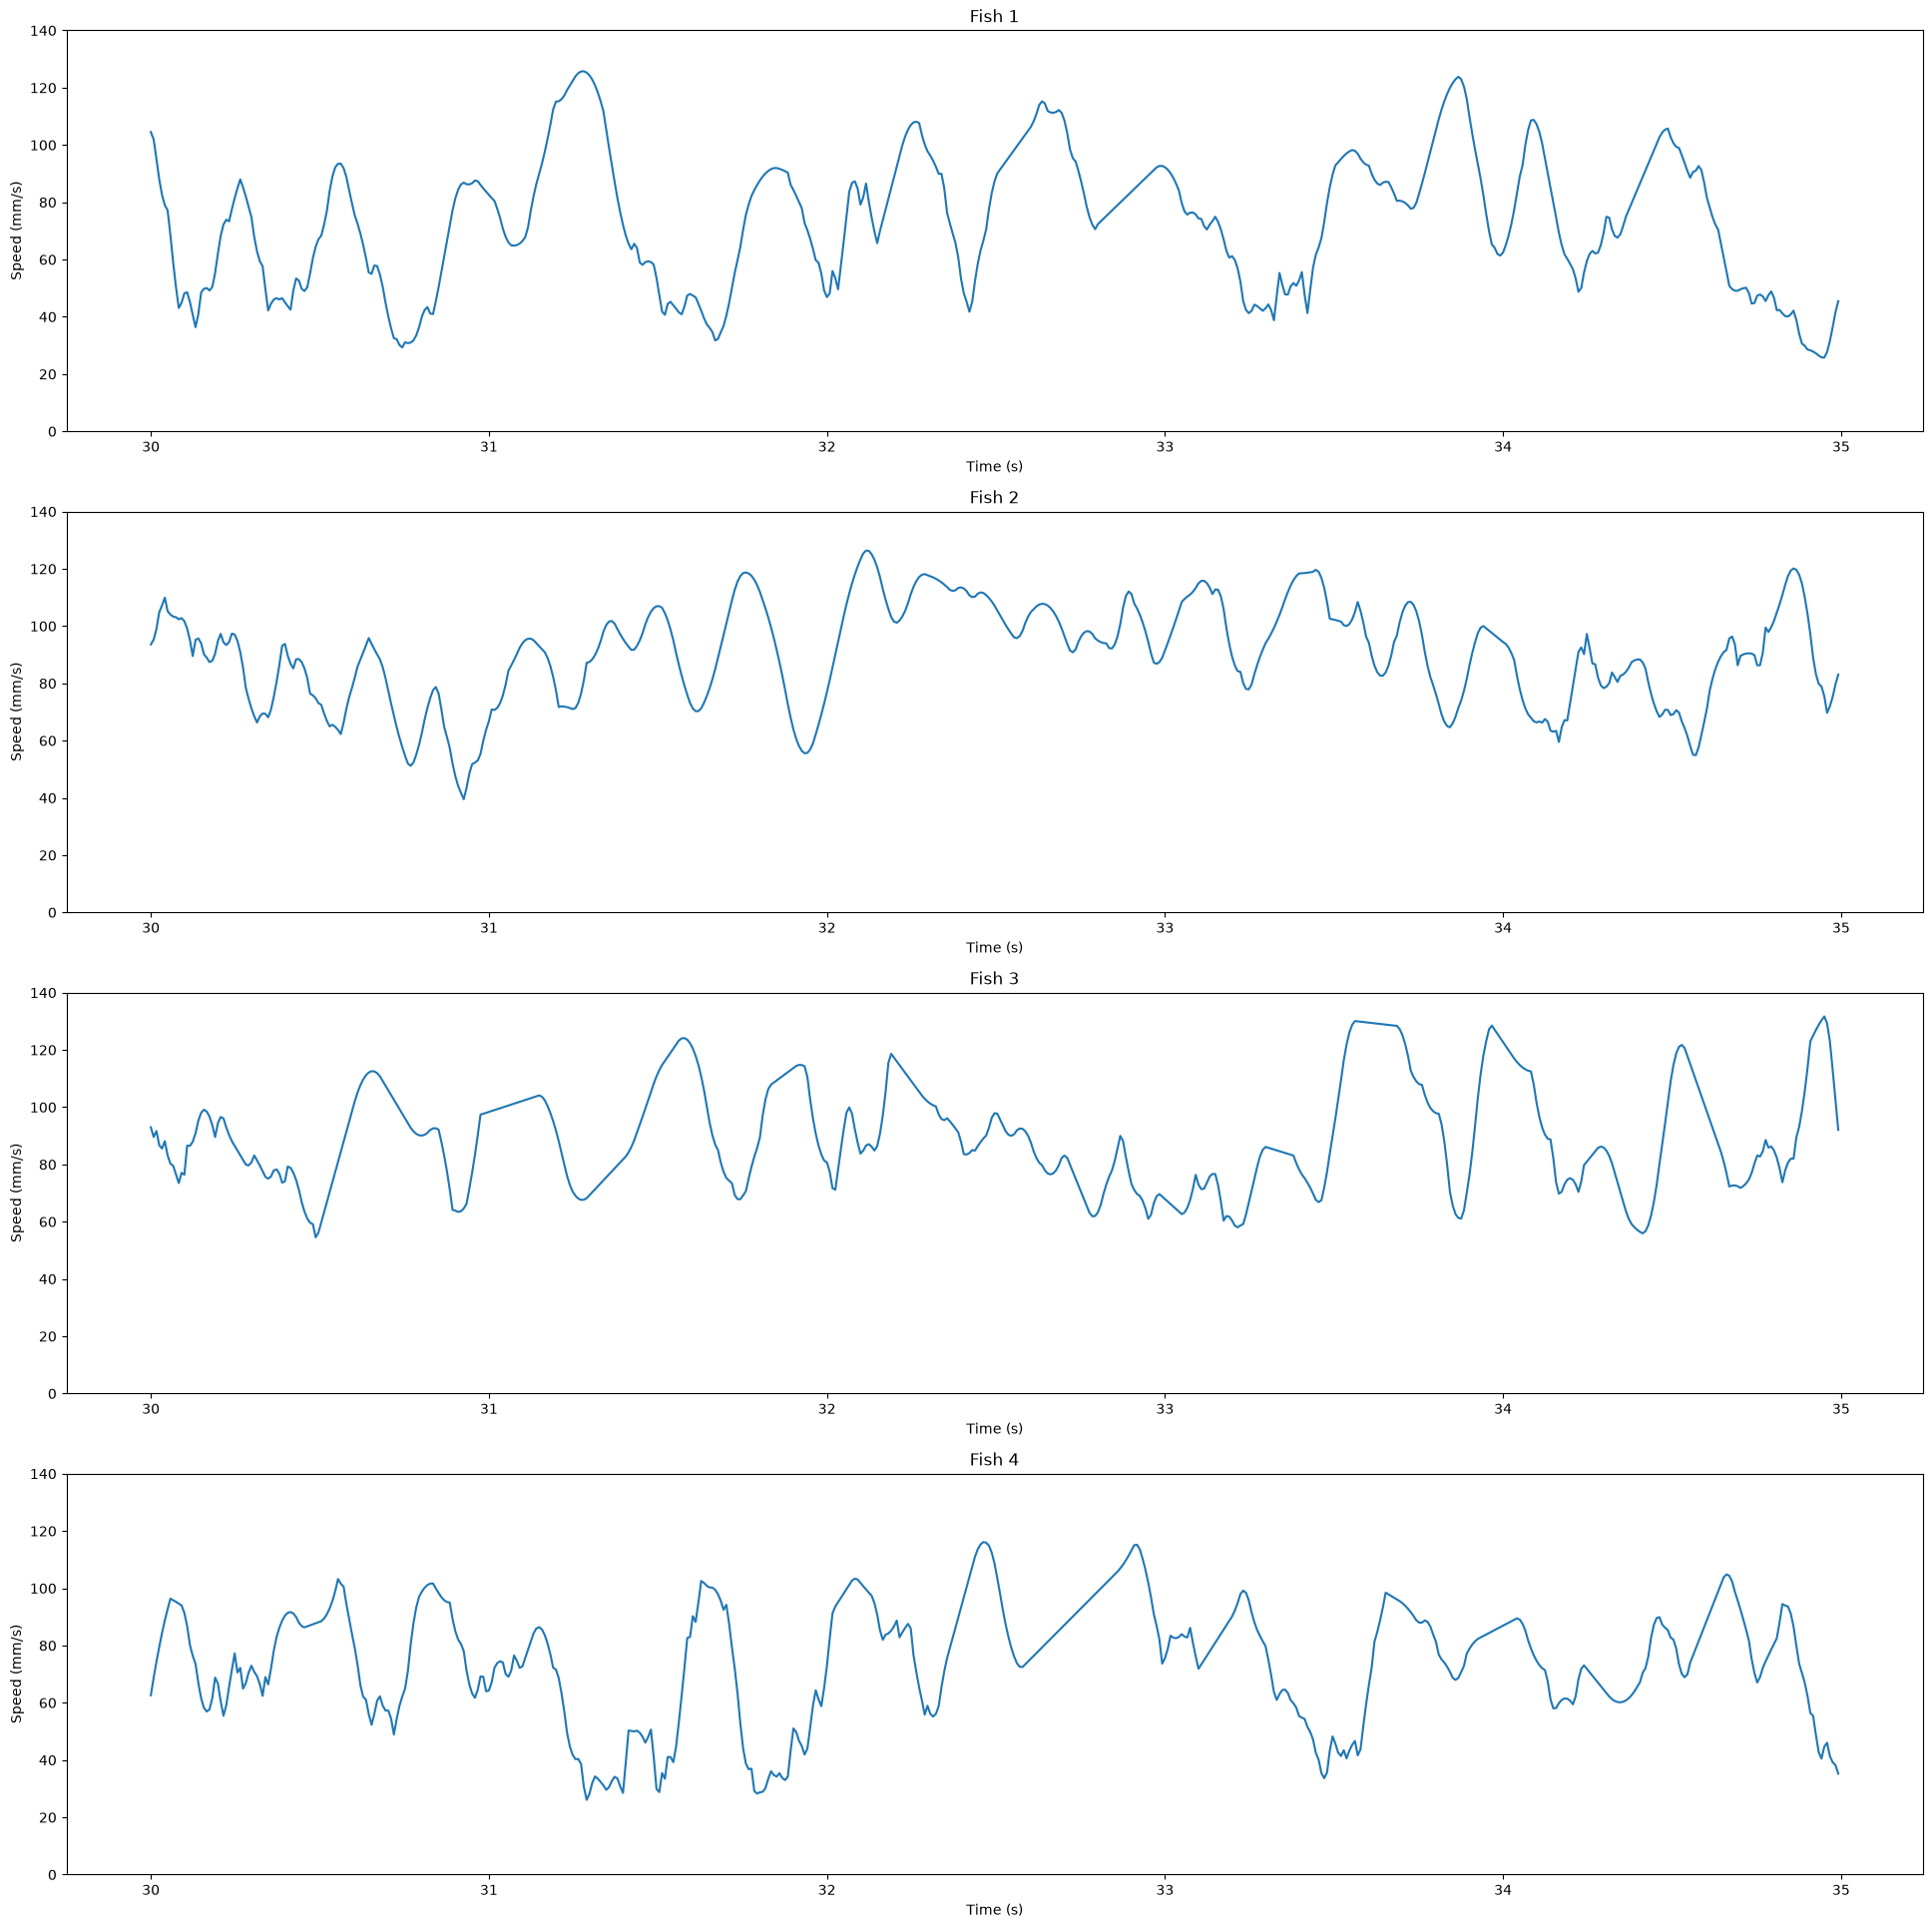

In [704]:
start_time=30
end_time=35
fig, ax=plt.subplots(4,1, figsize=(24, 24))
for i in range(4):
    ax[i].plot([j*frames_to_seconds+start_time for j in range(len(get_data_on_interval(f_speed,start_time, end_time)[i]))], get_speeds_on_interval(start_time, end_time)[i]*scale)
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Speed (mm/s)")
    ax[i].set_title(f"Fish {i+1}")
    ax[i].set_ylim(0, 140)
plt.show()


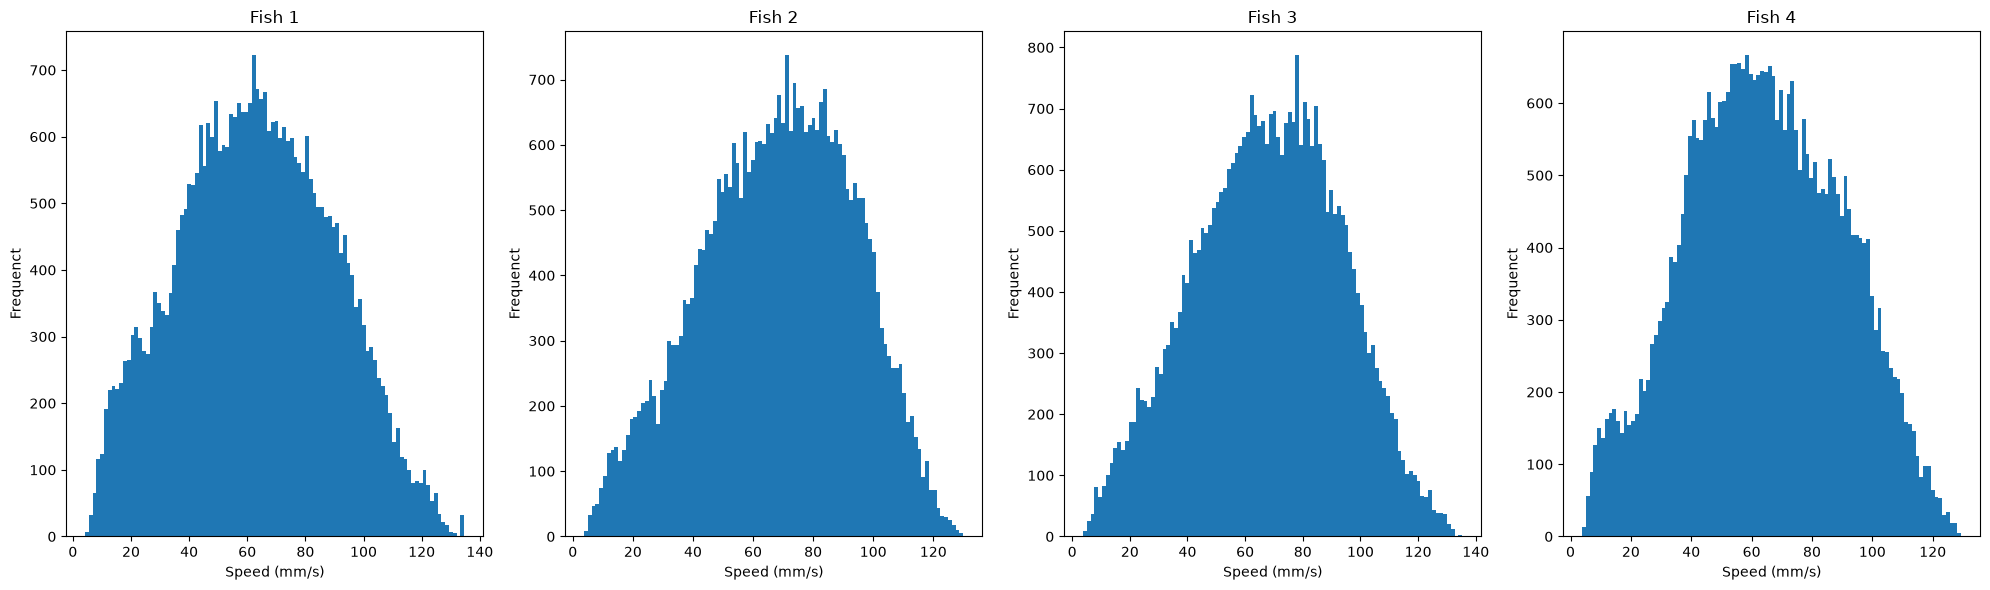

In [705]:

fig, ax=plt.subplots(1, 4, figsize=(20, 6))
for i in range(4):
    ax[i].hist(f_speed[i]*scale, bins=100)
    ax[i].set_xlabel("Speed (mm/s)")
    ax[i].set_ylabel("Frequenct")
    ax[i].set_title(f"Fish {i+1}")
fig.tight_layout()
plt.show()

In [706]:
def find_pausing(speeds):
    low_speed_counter=0
    pausing_intervals=[]
    for i, speed in enumerate(speeds):
        if speed*scale<10:
            low_speed_counter+=1
        else:
            if low_speed_counter*frames_to_seconds>0.25:
                pausing_intervals.append((((i-low_speed_counter)*frames_to_seconds), i*frames_to_seconds))
            low_speed_counter=0
    return pausing_intervals
    

0.3719008264462804
0.3801652892561833
0.3636363636363633
0.471074380165291


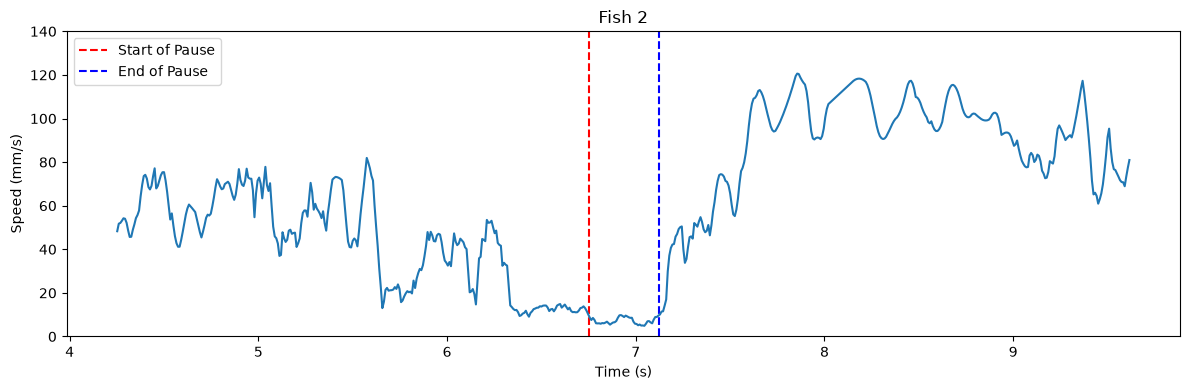

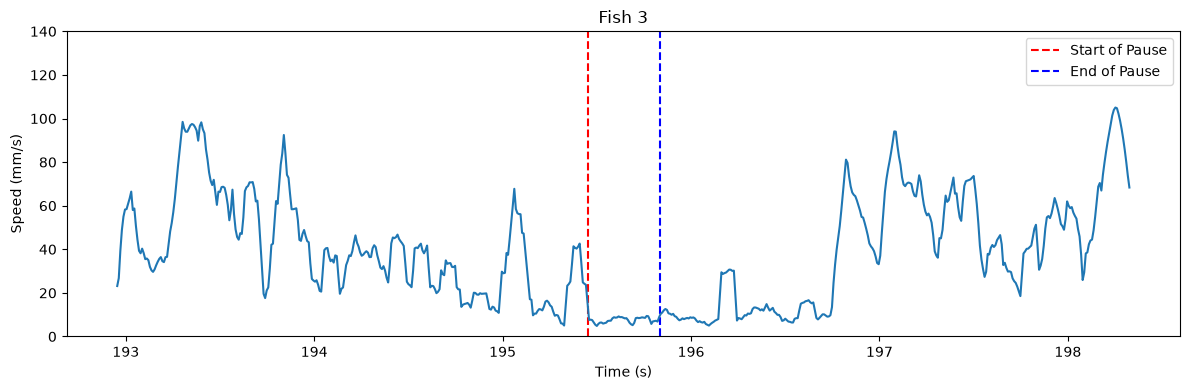

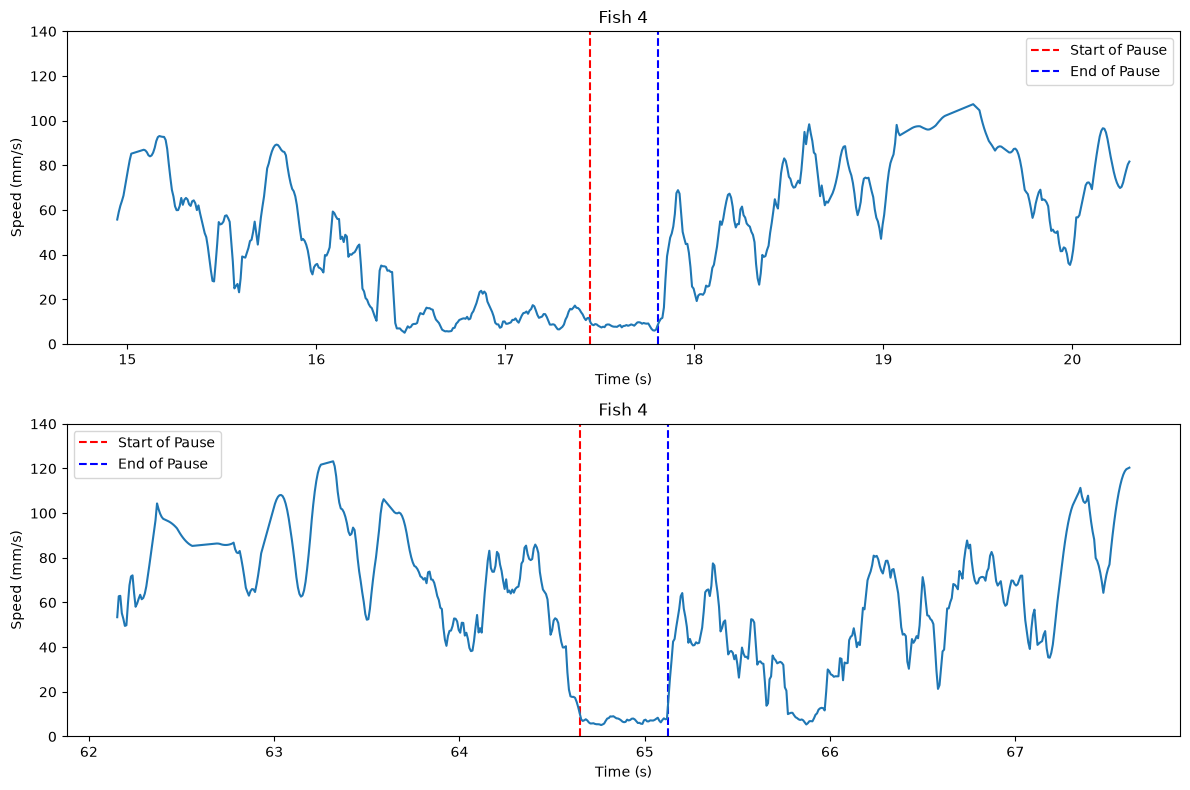

In [707]:
for i, speed in enumerate(f_speed):
    pausing_intervals=find_pausing(speed)
    if len(pausing_intervals)>1:
        fig, ax=plt.subplots(len(pausing_intervals), 1, figsize=(12, len(pausing_intervals)*4))
        for k, pausing_interval in enumerate(pausing_intervals):
            start_time, end_time=pausing_interval
            print(end_time-start_time)
            ax[k].axvline(start_time, c="r", linestyle="--", label="Start of Pause")
            ax[k].axvline(end_time, c="b", linestyle="--", label="End of Pause")
            start_time-=2.5
            end_time+=2.5
            ax[k].plot([j*frames_to_seconds+start_time for j in range(len(get_data_on_interval(f_speed,start_time, end_time)[i]))], get_speeds_on_interval(start_time, end_time)[i]*scale)
            ax[k].set_xlabel("Time (s)")
            ax[k].set_ylabel("Speed (mm/s)")
            ax[k].set_title(f"Fish {i+1}")
            ax[k].set_ylim(0, 140)
            ax[k].legend()
        fig.tight_layout()
    elif len(pausing_intervals)>0:
        fig, ax=plt.subplots(len(pausing_intervals), 1, figsize=(12, len(pausing_intervals)*4))
        start_time, end_time=pausing_intervals[0]
        print(end_time-start_time)
        ax.axvline(start_time, c="r", linestyle="--", label="Start of Pause")
        ax.axvline(end_time, c="b", linestyle="--", label="End of Pause")
        start_time-=2.5
        end_time+=2.5
        ax.plot([j*frames_to_seconds+start_time for j in range(len(get_data_on_interval(f_speed,start_time, end_time)[i]))], get_speeds_on_interval(start_time, end_time)[i]*scale)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Speed (mm/s)")
        ax.set_title(f"Fish {i+1}")
        ax.set_ylim(0, 140)
        ax.legend()
        fig.tight_layout()

In [708]:
def acceleration(speed):
    return np.gradient(speed, 0.0001)

IndexError: invalid index to scalar variable.

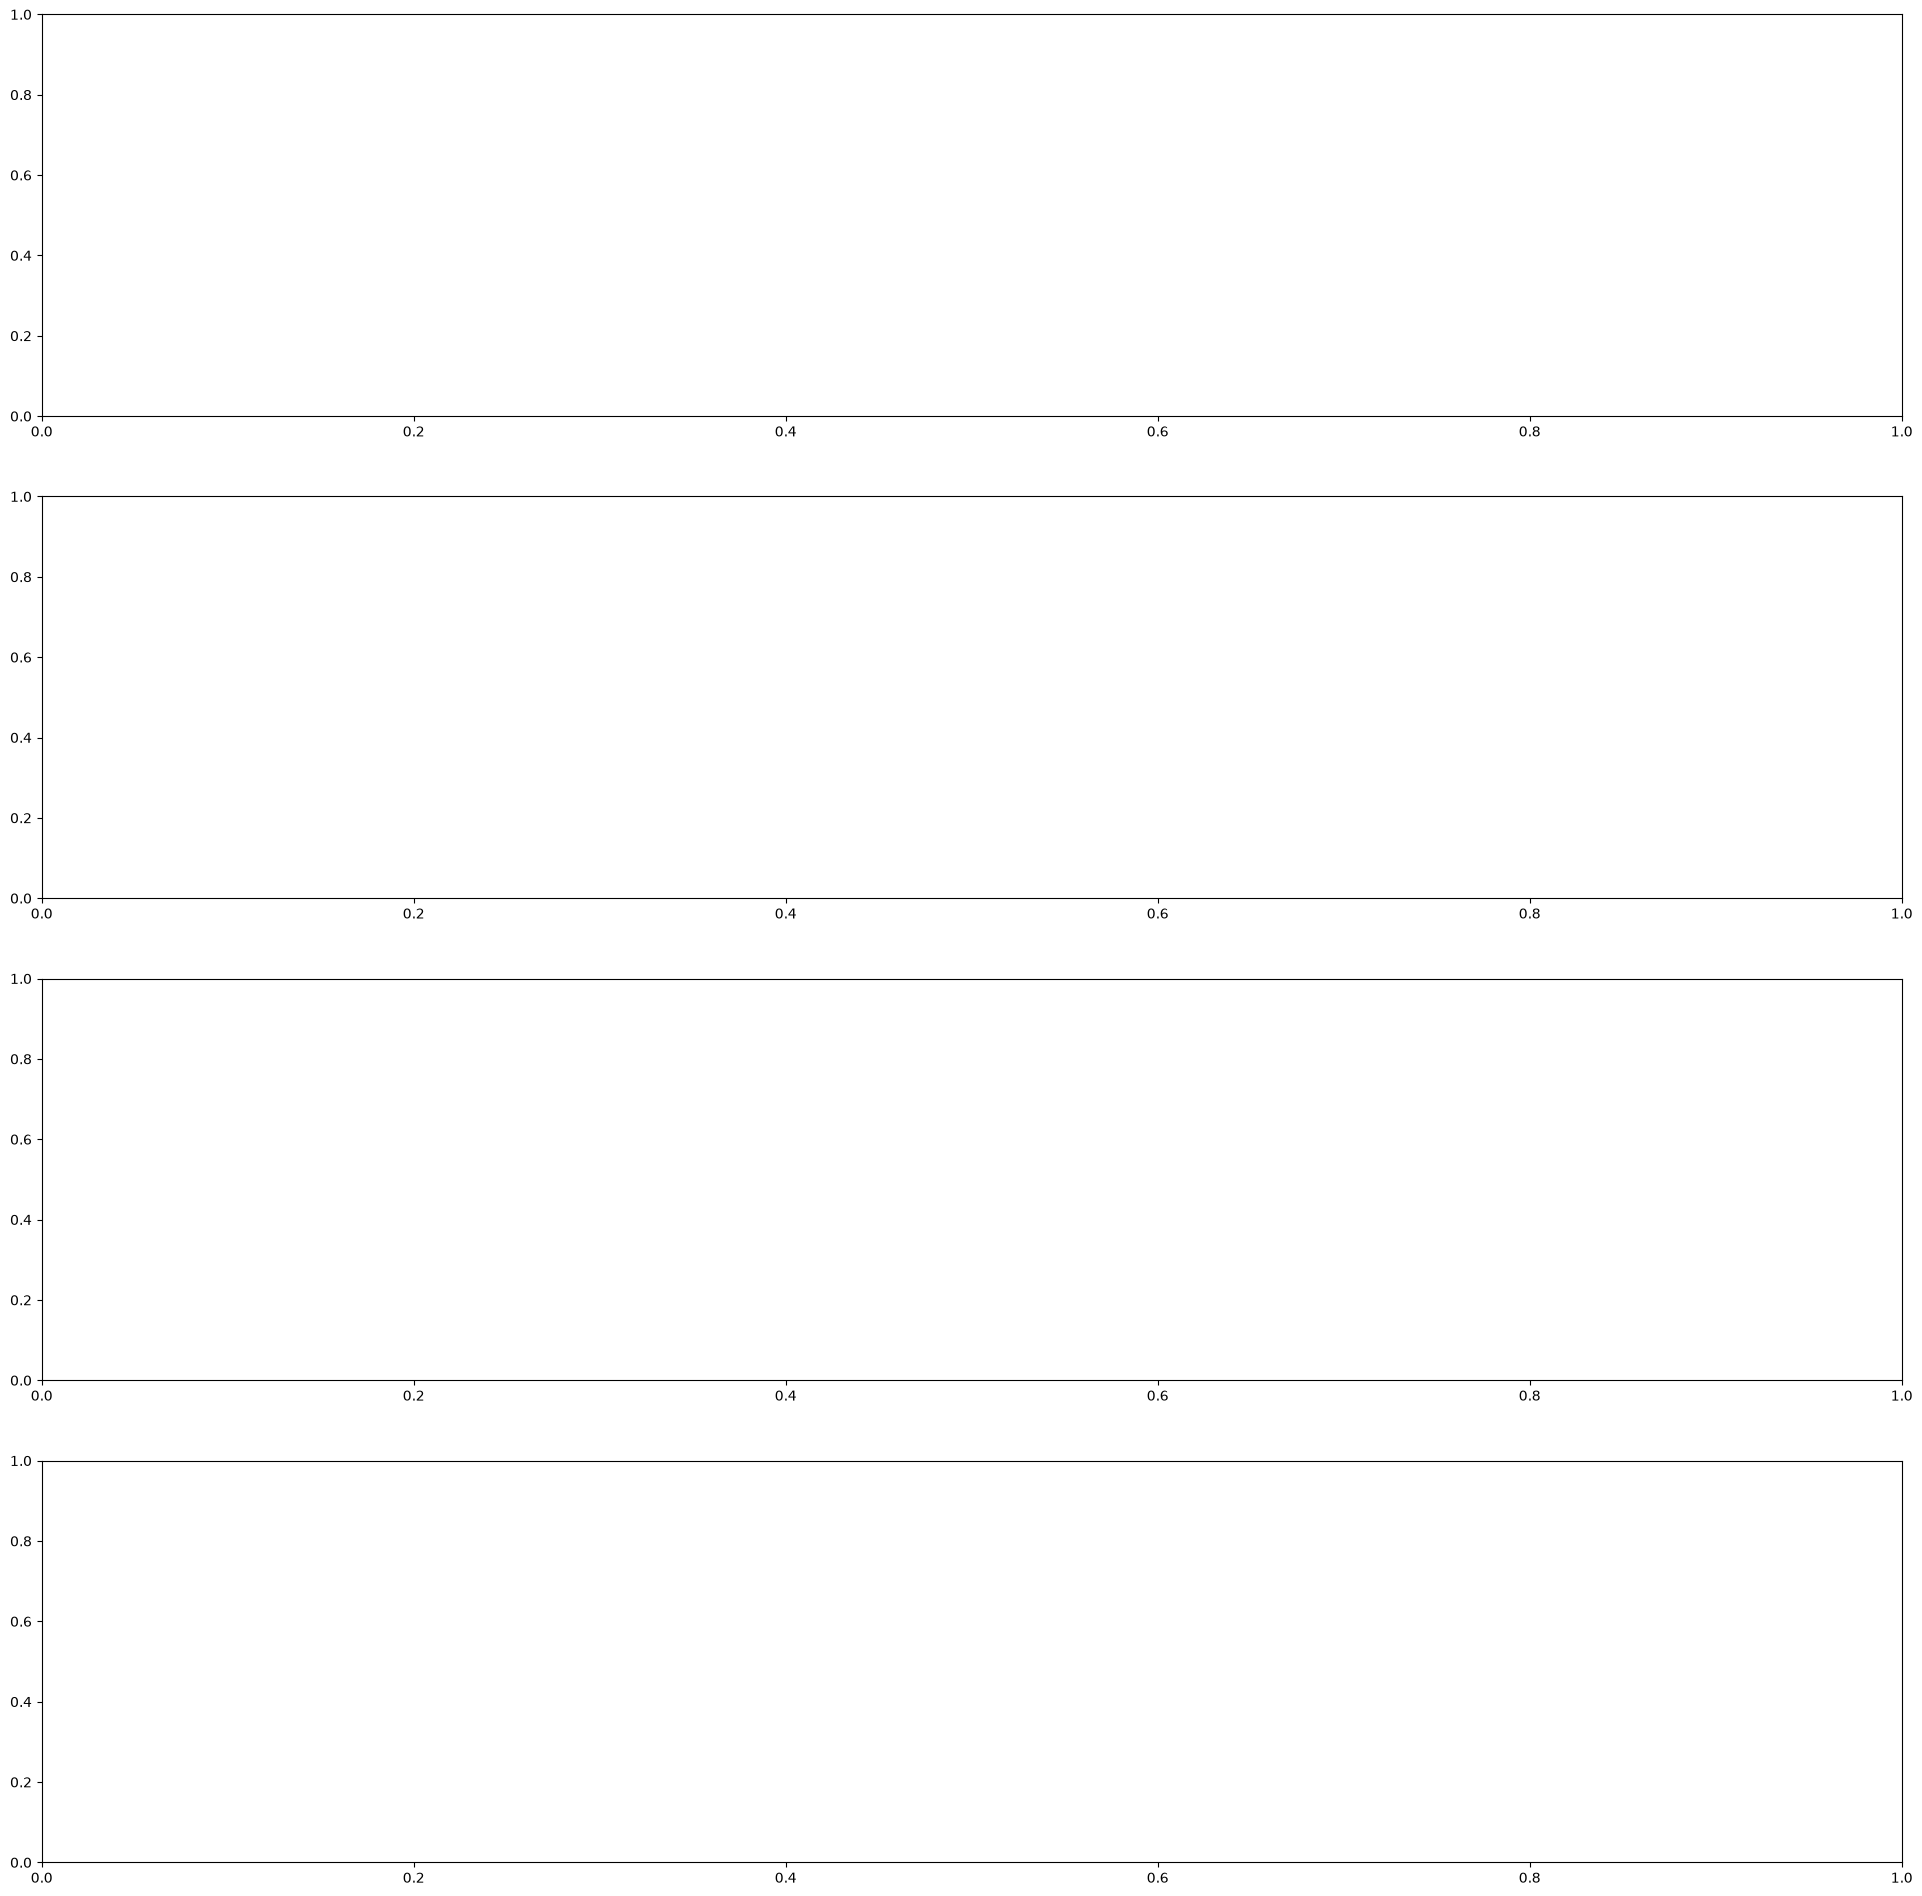

In [709]:
start_time=30
end_time=35
fig, ax=plt.subplots(4,1, figsize=(24, 24))
for i in range(4):
    accel=acceleration(f_speed[i])
    ax[i].plot([j*frames_to_seconds+start_time for j in range(len(get_data_on_interval(accel,  start_time, end_time)))], get_data_on_interval(accel,start_time, end_time)*scale)
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("Acceleration (mm/s/s)")
    ax[i].set_title(f"Fish {i+1}")
plt.show()